In [1]:
import numpy as np
import io

import matplotlib.pyplot as plt

import sys
import os

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(r'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [2]:
data_g_file = "./Data/anisotropy_g_sweep.h5"
g_data = AM.read_hdf5_as_dict(data_g_file)

In [3]:
g_data.keys()

dict_keys(['file0_N1000', 'file1_N4000', 'file2_N10000', 'file3_N51296', 'file4_N100000', 'lambda_um', 'nu', 'attrs'])

In [4]:
nu = g_data['nu']
lambdas = g_data['lambda_um']

In [10]:
g_data['attrs']

{'a_scale': 2.0501033142180396,
 'aspect_ratio': 2.5,
 'min_ewald_modes': 8,
 'minor_radius': 0.2252,
 'n_bg': 1.0,
 'n_rod': 2.9275,
 'polarized': False,
 'sweep_by': 'lambda',
 'target_dx': 0.07}

In [11]:
g_data['file0_N1000']['attrs']

{'N': 1000,
 'box': 11.439999999999998,
 'ends_file': 'Example/N1000/20260623_lsu_fromrandom_N1000_ends.txt',
 'ff': 0.2174386978149414,
 'grid': 163,
 'lam_gap': 5.011443430930854,
 'n_av': 1.626673495550174,
 'n_eff': 1.4969442175816463,
 'q_peak': 3.7536402608177886}

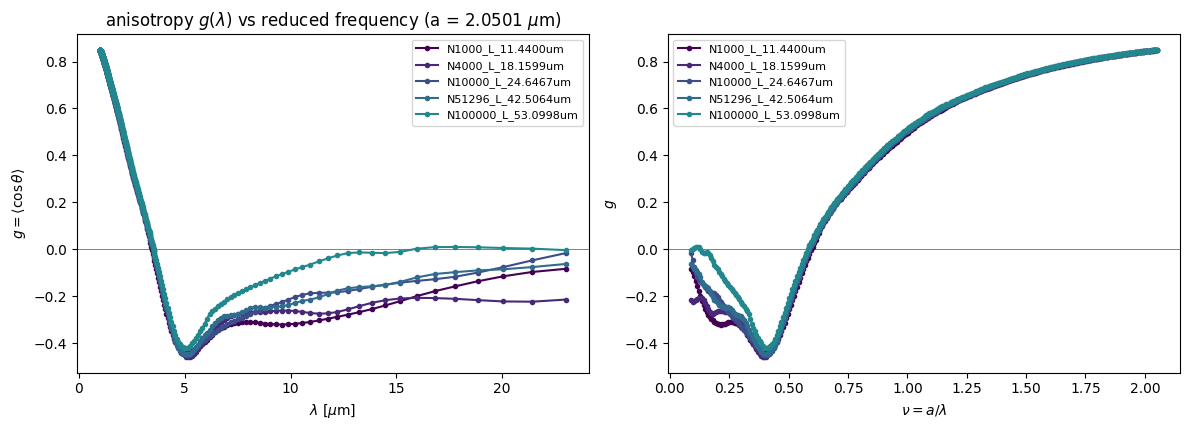

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for a in ax: a.axhline(0, c="grey", lw=.7)
g_list = []
header_list = []
colors = plt.cm.viridis(np.linspace(0, 0.82, len(g_data.keys())))
for R, c in zip(list(g_data.keys()), colors):
    if R in ["attrs", "nu", "lambda_um"]:  # Skip the metadata keys
        continue
    label = rf"N{g_data[R]["attrs"]["N"]}_L_{g_data[R]["attrs"]["box"]:.4f}"
    ax[0].plot(lambdas, g_data[R]["g_avg"], "o-", ms=3, color=c, label=label+"um")
    g_list.append(g_data[R]["g_avg"])
    header_list.append(label)
    ax[1].plot(nu,  g_data[R]["g_avg"], "o-", ms=3, color=c, label=label+"um")

ax[0].set(xlabel=rf"$\lambda$ [$\mu$m]", ylabel=r"$g=\langle\cos\theta\rangle$")
ax[0].legend(fontsize=8)
ax[1].set(xlabel=rf"$\nu = a/\lambda$", ylabel=r"$g$")
ax[1].legend(fontsize=8)
ax[0].set_title(rf"anisotropy $g(\lambda)$ vs reduced frequency (a = {g_data['attrs']['a_scale']:.4f} $\mu$m)")
plt.tight_layout()
filename =rf"./Data/g_data_processed/n_rod_{g_data['attrs']['n_rod']}_ff_{g_data['file0_N1000']['attrs']['ff']:.4f}"
os.makedirs('Data/g_data_processed', exist_ok=True)
plt.savefig(rf"{filename}.png", dpi=300)
plt.show()


In [36]:
#Store txt for Frank
headers = " ".join(["lambda_um", "nu"] + header_list)
np.savetxt(rf"{filename}.txt", np.transpose([lambdas, nu] + g_list), fmt="%.18f", delimiter=" ", header=headers, comments="")
